# Extracción

# ## Carga de Datos y Librerías

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df= pd.read_json("https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json")

In [4]:
print(f"   Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

   Dimensiones: 7267 filas x 6 columnas


## Vista Inicial de los Datos

In [5]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


##TRASFORMACION DE LOS DATOS

##2. Desanidado de Datos JSON

In [7]:
#Normalizando
df_customer=pd.json_normalize(df["customer"])
df_phone=pd.json_normalize(df["phone"])
df_internet=pd.json_normalize(df["internet"])
df_account=pd.json_normalize(df["account"])

In [8]:
# Concatenar todos los dataframes normalizados
df_normalizado= pd.concat([df[["customerID","Churn"]], df_customer, df_phone, df_internet, df_account], axis=1)
pd.set_option('display.max_columns', None)
df_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
print(f"   Dimensiones finales: {df_normalizado.shape[0]} filas x {df_normalizado.shape[1]} columnas")

   Dimensiones finales: 7267 filas x 21 columnas


In [10]:
df_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


##2 Exploración del Dataset Normalizado

In [11]:
# Información detallada
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [12]:
#Verificando que valores tenemos
for col in df_normalizado.columns:
    print(df_normalizado[col].unique())

['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
['No' 'Yes' '']
['Female' 'Male']
[0 1]
['Yes' 'No']
['Yes' 'No']
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]
['Yes' 'No']
['No' 'Yes' 'No phone service']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['One year' 'Month-to-month' 'Two year']
['Yes' 'No']
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
[65.6  59.9  73.9  ... 91.75 68.8  67.85]
['593.3' '542.4' '280.85' ... '742.9' '4627.65' '3707.6']


##Verificación de Nulos

In [13]:
#Verificando que no exista nulos
df_normalizado.isna().sum().rename("Nulos")

,Nulos
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


## Verificación de Duplicados

In [14]:
datos_duplicados = df_normalizado.duplicated().sum()
print(f"Registros encontrados duplicados: {datos_duplicados}")


Registros encontrados duplicados: 0


[texto del vínculo](https://)###Detección de problemas

In [15]:
df_normalizado["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [16]:
df_normalizado=df_normalizado.query('Churn!=""')

In [17]:
# Buscar valores no numéricos en Charges.Total
df_normalizado[~df_normalizado['Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')].head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,


In [18]:
df_normalizado=df_normalizado[df_normalizado['Charges.Total'].astype(str).str.contains(r'^-?\d*\.?\d+$')]

In [19]:
#Creando la columna cuentas diarias
df_normalizado["Cuentas_diarias"]=(df_normalizado['Charges.Monthly']/30).round(3)

In [20]:
columnas_tf= ["Churn",
              "Partner",
              "Dependents",
              "PaperlessBilling",
              "OnlineSecurity",
              "OnlineBackup",
              "DeviceProtection",
              "TechSupport",
              "StreamingTV",
              "StreamingMovies",
              "PhoneService",
              "MultipleLines"]

In [21]:
#Ajustando datos
ajustando_tf= df_normalizado[columnas_tf]
for var in ajustando_tf.columns:
  df_normalizado[var]=df_normalizado[var].apply(lambda x: x.replace("No internet service", "0").replace("No phone service", "0").replace("No", "0").replace("Yes", "1"))


In [22]:
df_normalizado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.60,593.3,2.187
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.4,1.997
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.267
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.4,2.797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,1,0,0,1,0,0,One year,0,Mailed check,55.15,742.9,1.838
7263,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.7,2.837
7264,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.677
7265,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.262


## Conversión de Tipo de Datos

In [23]:
df_normalizado[columnas_tf]=df_normalizado[columnas_tf].astype(np.int64)
df_normalizado['Charges.Total']=df_normalizado["Charges.Total"].astype(np.float64)

In [24]:
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   int64  
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   int64  
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   int64  
 11  OnlineBackup      7032 non-null   int64  
 12  DeviceProtection  7032 non-null   int64  
 13  TechSupport       7032 non-null   int64  
 14  StreamingTV       7032 non-null   int64  
 15  StreamingMovies   7032 non-null   int64  
 16  Contract          7032 non-null   object 
 17  

##2.6 Reorganizando

In [25]:
name_columns= {"customerID": "ID",
               "Churn": "Abandonó_Servicio",
               "gender": "Género",
               "SeniorCitizen": "Cliente_Señor",
               "Partner": "Tiene_Pareja",
               "Dependents": "Tiene_Dependientes",
               "tenure": "Antigüedad",
               "PhoneService": "Servicio_Telefónico",
               "MultipleLines": "Múltiples_Líneas",
               "InternetService": "Servicio_Internet",
               "OnlineSecurity": "Seguridad_Online",
               "OnlineBackup": "Respaldo_Online",
               "DeviceProtection": "Protección_Dispositivo",
               "TechSupport": "Soporte_Técnico",
               "StreamingTV": "TV_Streaming",
               "StreamingMovies": "Películas_Streaming",
               "Contract": "Tipo_Contrato",
               "PaperlessBilling": "Facturación_Sin_Papel",
               "PaymentMethod": "Método_Pago",
               "Charges.Monthly": "Cargo_Mensual",
               "Charges.Total": "Cargo_Total",
               "Cuentas_diarias": "Cargo_Diario"}

In [26]:
df_normalizado=df_normalizado.rename(columns=name_columns)

In [27]:
df_normalizado.sample(6)

,ID,Abandonó_Servicio,Género,Cliente_Señor,Tiene_Pareja,Tiene_Dependientes,Antigüedad,Servicio_Telefónico,Múltiples_Líneas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Protección_Dispositivo,Soporte_Técnico,TV_Streaming,Películas_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
1090,1545-ACTAS,0,Female,0,1,1,48,1,0,Fiber optic,1,0,1,0,1,1,One year,1,Bank transfer (automatic),99.70,4977.20,3.323
1488,2138-VFAPZ,0,Female,0,1,1,14,1,0,No,0,0,0,0,0,0,Two year,1,Mailed check,19.70,263.65,0.657
6497,8930-XOTDP,0,Female,0,1,1,18,1,0,DSL,0,0,0,0,1,0,Month-to-month,0,Mailed check,55.95,1082.80,1.865
426,0613-WUXUM,0,Female,0,1,1,70,1,0,No,0,0,0,0,0,0,Two year,1,Mailed check,19.20,1401.40,0.640
7022,9667-TKTVZ,0,Female,0,0,0,2,1,1,DSL,0,0,0,1,0,0,Month-to-month,1,Mailed check,54.35,117.05,1.812
120,0203-HHYIJ,1,Male,0,0,0,25,1,1,No,0,0,0,0,0,0,One year,0,Bank transfer (automatic),25.30,676.35,0.843


In [28]:
#Verificando que valores tenemos
for col in df_normalizado.columns:
    print(df_normalizado[col].unique())

['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
[0 1]
['Female' 'Male']
[0 1]
[1 0]
[1 0]
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
[1 0]
[0 1]
['DSL' 'Fiber optic' 'No']
[0 1]
[1 0]
[0 1]
[1 0]
[1 0]
[0 1]
['One year' 'Month-to-month' 'Two year']
[1 0]
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
[65.6  59.9  73.9  ... 91.75 68.8  67.85]
[ 593.3   542.4   280.85 ...  742.9  4627.65 3707.6 ]
[2.187 1.997 2.463 ... 3.058 2.293 2.262]


In [29]:
name_values={"Female":"Femenino",
             "Male":"Masculino",
             "Fiber optic":"Fibra optica",
             "One year":"Anual",
             "Month-to-month":"Mensual",
             "Two year":"Bienal",
             "Mailed check": "Cheque enviado por correo",
             "Electronic check": "Cheque electrónico",
             "Credit card (automatic)": "Tarjeta de crédito (automático)",
             "Bank transfer (automatic)": "Transferencia bancaria (automática)"}

In [30]:
df_normalizado.replace(name_values, inplace=True)

In [31]:
df_normalizado.sample(3)

,ID,Abandonó_Servicio,Género,Cliente_Señor,Tiene_Pareja,Tiene_Dependientes,Antigüedad,Servicio_Telefónico,Múltiples_Líneas,Servicio_Internet,Seguridad_Online,Respaldo_Online,Protección_Dispositivo,Soporte_Técnico,TV_Streaming,Películas_Streaming,Tipo_Contrato,Facturación_Sin_Papel,Método_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
4209,5781-RFZRP,0,Masculino,0,1,0,71,1,1,DSL,1,1,0,1,1,0,Bienal,0,Tarjeta de crédito (automático),73.5,5357.75,2.45
4004,5478-JJVZK,0,Femenino,0,0,0,33,1,1,DSL,1,1,0,0,0,0,Mensual,1,Cheque enviado por correo,60.9,2033.85,2.03
3510,4835-YSJMR,0,Masculino,0,0,0,39,1,0,DSL,0,0,0,1,0,0,Bienal,1,Transferencia bancaria (automática),49.8,1971.15,1.66


In [32]:
#Verificando que el indice este correcto
df_normalizado.index.equals(pd.RangeIndex(start=0, stop=len(df_normalizado), step=1))

False

In [33]:
#Reseteando índice
df_normalizado.reset_index(drop=True, inplace=True)

In [34]:
#Verificando que el indice este correcto
df_normalizado.index.equals(pd.RangeIndex(start=0, stop=len(df_normalizado), step=1))

True

# Carga y análisis

##3 **Análisis descriptivo**<br>
Con el método describe, podemos ver las estadísticas descriptivas de nuestro DF. El análisis descriptivo ayuda con la comprensión de la distribución y el comportamiento de los clientes de Telecom X.

Se hará foco en la media (mean), mediana(50% o segundo cuartil) y desviación estándar(std).

In [35]:
df_describe=df_normalizado.describe().T

In [36]:
estilo_descripcion = df_describe.style
estilo_descripcion.format({"count": "{:.0f}",
                           "mean": "{:.2%}",
                           "std": "{:.2%}",
                           "25%": "{:.2%}",
                           "50%": "{:.2%}",
                           "75%": "{:.2%}",
                           "max": "{:.2f}",
                           "min": "{:.2f}"
                        })


,count,mean,std,min,25%,50%,75%,max
Abandonó_Servicio,7032,26.58%,44.18%,0.00,0.00%,0.00%,100.00%,1.00
Cliente_Señor,7032,16.24%,36.88%,0.00,0.00%,0.00%,0.00%,1.00
Tiene_Pareja,7032,48.25%,49.97%,0.00,0.00%,0.00%,100.00%,1.00
Tiene_Dependientes,7032,29.85%,45.76%,0.00,0.00%,0.00%,100.00%,1.00
Antigüedad,7032,3242.18%,2454.53%,1.00,900.00%,2900.00%,5500.00%,72.00
Servicio_Telefónico,7032,90.33%,29.56%,0.00,100.00%,100.00%,100.00%,1.00
Múltiples_Líneas,7032,42.19%,49.39%,0.00,0.00%,0.00%,100.00%,1.00
Seguridad_Online,7032,28.65%,45.22%,0.00,0.00%,0.00%,100.00%,1.00
Respaldo_Online,7032,34.49%,47.54%,0.00,0.00%,0.00%,100.00%,1.00
Protección_Dispositivo,7032,34.39%,47.50%,0.00,0.00%,0.00%,100.00%,1.00


**Observaciones Clave:**


*   La mayoría de servicios tiene adopción entre 29-48% (streaming, protecciones, soporte)
*   Servicio Telefónico: muy alta adopción (90.33%)
*   Facturación Sin Papel: mayoría usa este método (59.27%)
*   Churn: 26.58% de abandono - tasa significativa para atender
*   Solo 16.24% son clientes senior
*   48.25% tiene pareja
*   29.85% tiene dependientes
*   Media de 32 meses con alta variabilidad (std: 2454)
*   Rango muy amplio: 1 a 72 meses
*   Mensual: promedio \$64.80 (rango: \$18.25 - \$118.75)
*   Total: promedio \$2,283 (alta variación: \$16.80 - \$8,684)

**Conclusiones generales de lo interpretado:**
*   Alta variabilidad en antigüedad y gastos sugiere diferentes segmentos de
clientes.
*   La tasa de abandono del 26.58% requiere atención inmediata.
*   Existe oportunidad de retener clientes de alto valor con antigüedad prolongada.

##3.2 Distribución de evasión (Churn) de los clientes

In [37]:
df_evasion=df_normalizado['Abandonó_Servicio'].value_counts(normalize=True).rename(index={1:"Si",0:"No"})*100
df_evasion

,proportion
Abandonó_Servicio,
No,73.421502
Si,26.578498


In [38]:
colores = ['skyblue', 'salmon']
leyenda_nuevos = ["Clientes fieles", "Clientes perdidos"]
desfase = (0, 0.1)
def grafica_evasion():
    #Creando los subplots
    fig, axs =plt.subplots(1,2, figsize=(10,8))
    fig.suptitle("Graficas de Evasion de cliente", fontsize=18, fontweight="bold")
    #Gráfica de barras
    axs[0].bar(df_evasion.index, df_evasion.values, color=colores)
    axs[0].set_ylabel("Porcentaje de Evasión", fontsize=12, fontweight="bold")
    axs[0].set_xlabel("Categorías de Evasión", fontsize=12, fontweight="bold")
    axs[0].spines['top'].set_visible(False)
    axs[0].spines['right'].set_visible(False)
    for i, j in enumerate(df_evasion.values):
        axs[0].text(i,j+2,str(j.round(2))+"%",ha="center",va="center")
    #Gráfica de dona
    axs[1].pie(df_evasion, labels=df_evasion.index, colors=colores, autopct="%1.2f%%", explode=desfase, shadow=True)
    centro_circulo = plt.Circle((0,0), 0.70, fc='white')
    axs[1].add_artist(centro_circulo)
    axs[1].text(0, 0.1, "Tasa de\nEvasión",ha='center', va='center', fontsize=12, color='gray')
    axs[1].text(0, -0.2, f"{df_evasion.Si.round(2)}%", ha='center', va='center', fontsize=18, fontweight='bold', color='red')
    axs[1].legend(title="Categorías", loc="upper left", bbox_to_anchor=(0.7, 1.2), labels=leyenda_nuevos)
    fig.savefig("grafico_evasion_cliente.jpg", transparent=True)
    return plt

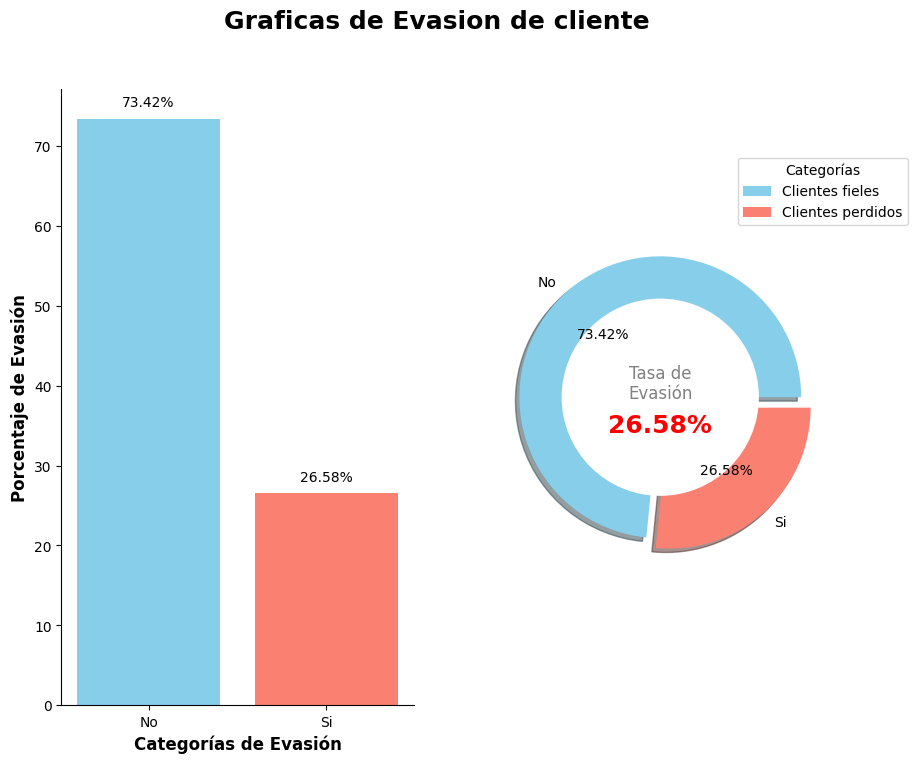

In [39]:
grafica_evasion().show()

### 📋 Observaciones
---
* **Tasa de Evasión actual:** `26.58%`
* **Conclusión:** Se observa que 1 de cada 4 clientes decide abandonar el servicio.
* **Recomendación Estratégica: Dado que la tasa de abandono supera el 20%, es urgente revisar las estrategias de retención y analizar los motivos de salida en el segmento "Si" para frenar la pérdida.**


##3.3 Recuento de evasión por variables categóricas

In [40]:
#Variables categóricas
variables_categoricas = ["Género", "Tipo_Contrato", "Método_Pago", "Servicio_Internet", "Facturación_Sin_Papel", "Tiene_Pareja", "Tiene_Dependientes", "Cliente_Señor"]
extension=len(variables_categoricas)

In [41]:
cut_df=pd.cut(df_normalizado['Antigüedad'], bins=[0,18,36,54,72])
import seaborn as sns

In [42]:
def grafica_evasion_categorica():
    #Creando los subplots
  fig, axs = plt.subplots(4,2, figsize=(14,22))
  fig.subplots_adjust(hspace=1, wspace= 0.6, top=0.92)
  axs_planos = axs.ravel()

  for idx, v in enumerate(variables_categoricas):
      # Creando tabla
      tabla = pd.crosstab(index=df_normalizado[v], columns=df_normalizado['Abandonó_Servicio'])
      tabla_porcentaje = tabla.div(tabla.sum(1), axis=0) * 100
      #   Graficando
      tabla_porcentaje.plot(kind="bar", stacked=True, ax=axs_planos[idx], color=colores)
      # 4. Agregando los porcentajes
      for contenedor in axs_planos[idx].containers:
          axs_planos[idx].bar_label(contenedor,fmt='%.1f%%',label_type='center',color='white',fontweight='bold',fontsize=10)
      axs_planos[idx].tick_params(axis='x', labelrotation=45)
      axs_planos[idx].set_ylim(0, 110)
      axs_planos[idx].set_ylabel("Porcentaje (%)")
  # Ajustes finales
  for ax in axs_planos:
      ax.legend(labels=["No Abandonó", "Sí Abandonó"])
      ax.grid(linestyle=":", axis='y')
      ax.xaxis.label.set(fontsize=12, fontweight="bold")

  plt.tight_layout()
  fig.savefig("grafico_porcentajes.jpg", transparent=True)
  return plt

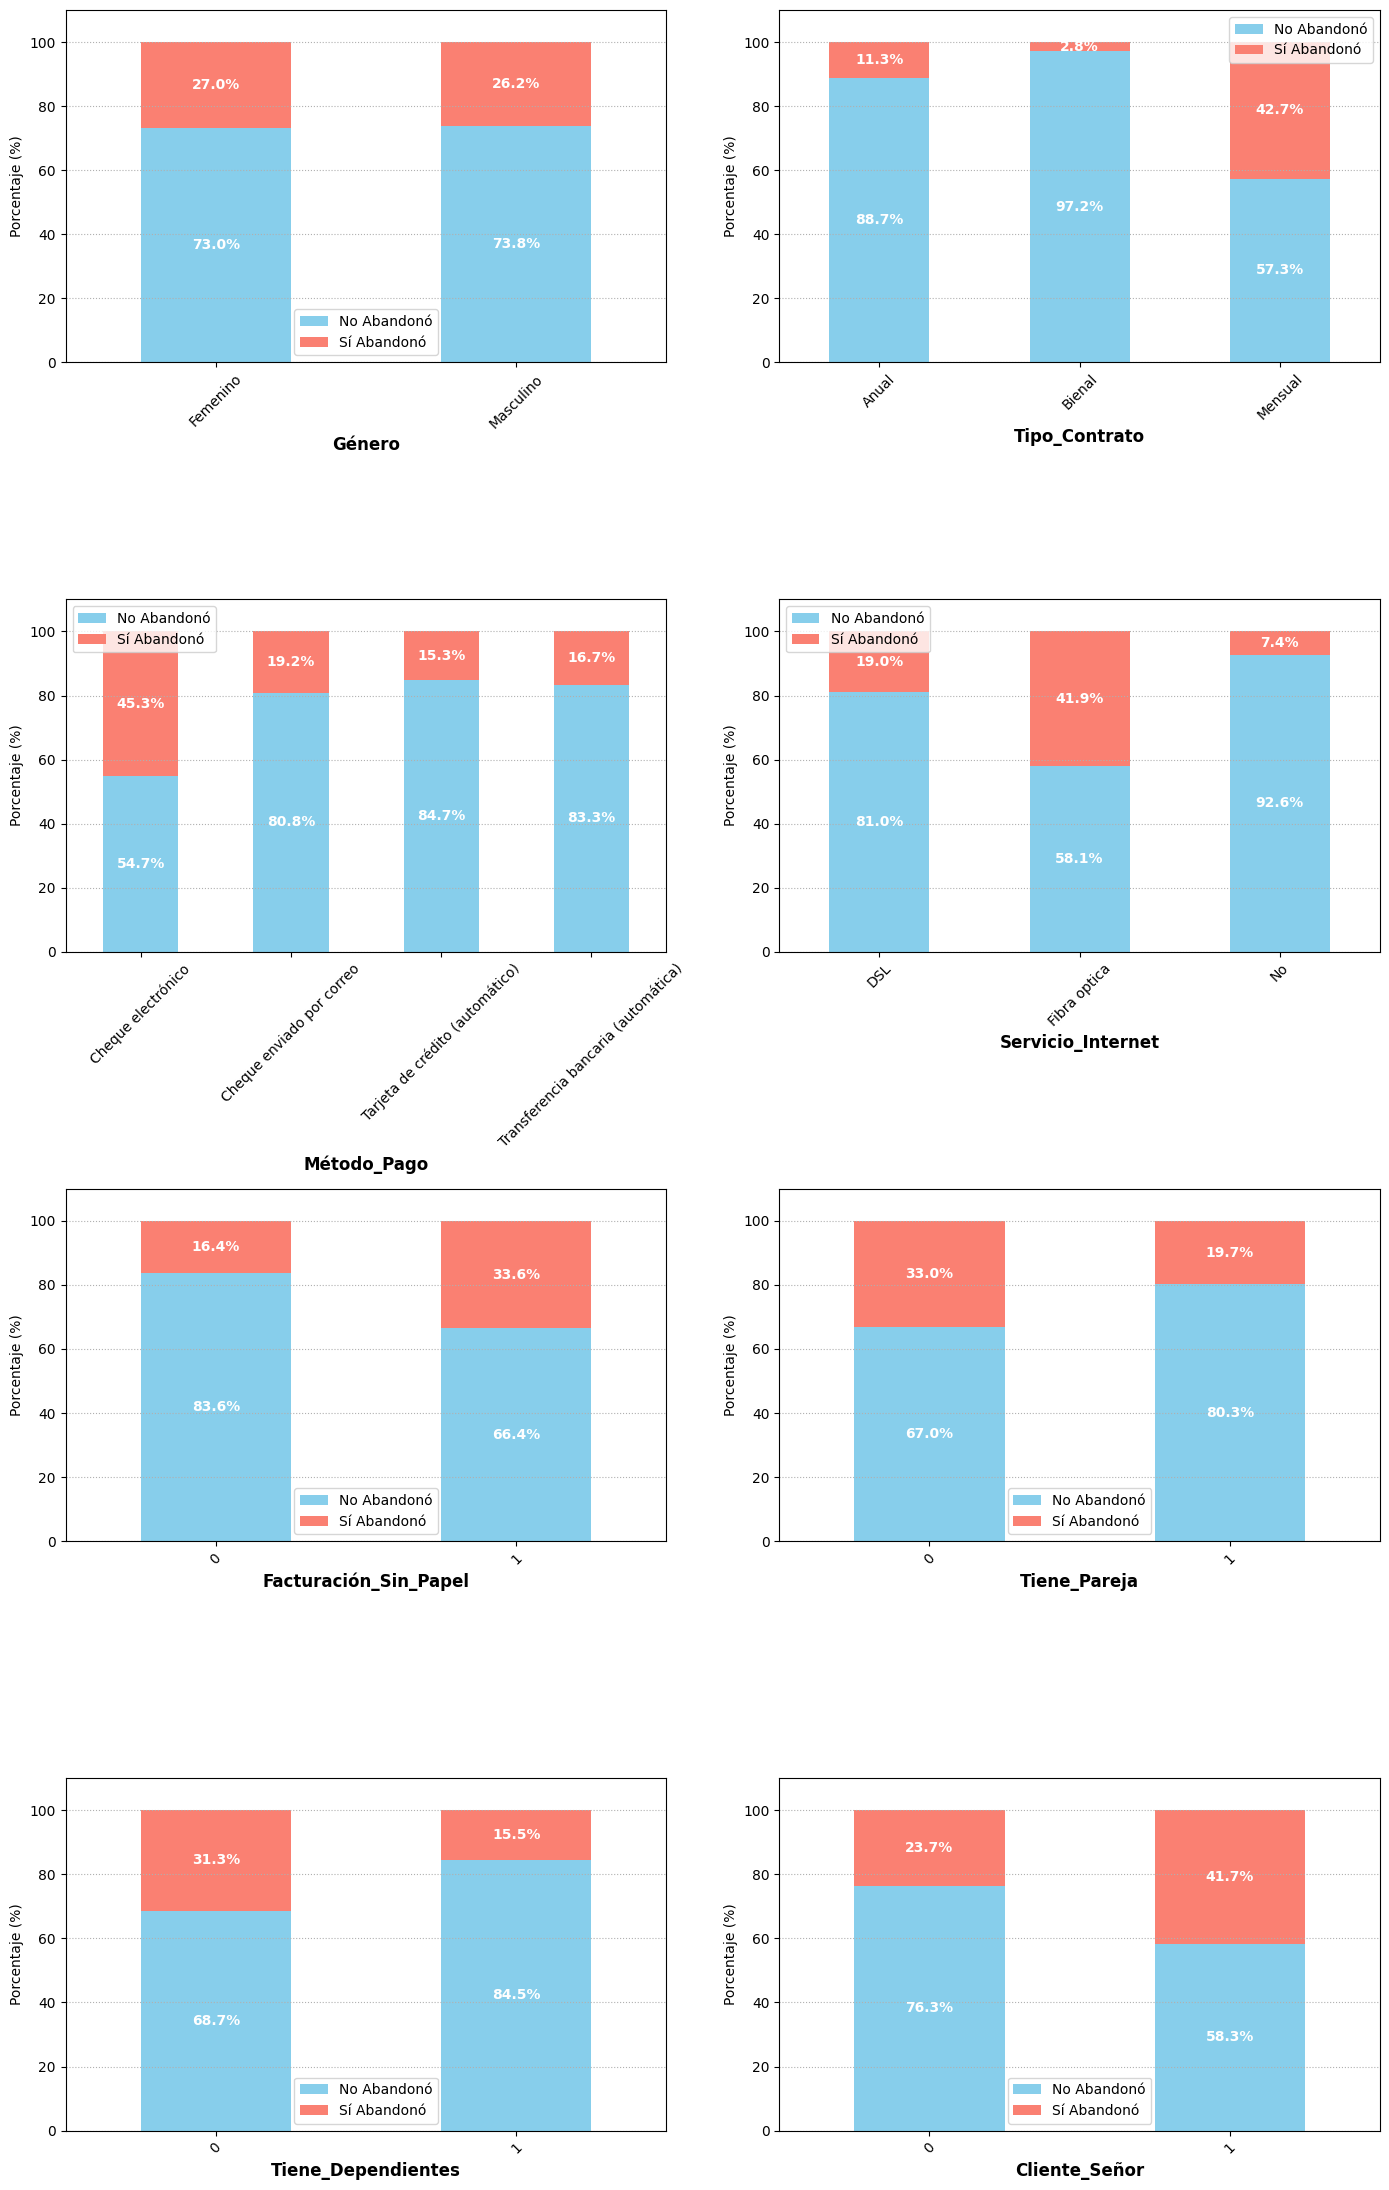

In [43]:
grafica_evasion_categorica().show()

**📋 Observaciones**
### Mayor Riesgo de Abandono
- **Contrato Mensual**: 42.7% churn
- **Fibra Óptica**: 41.9% churn  
- **Cliente Senior**: 41.7% churn
- **Cheque Electrónico**: 45.3% churn

### Conclusión Principal

El perfil de mayor riesgo combina: **contrato mensual + fibra óptica + pago electrónico + sin vínculos familiares**. Los contratos a largo plazo reducen drásticamente el churn.

##3.4 Conteo de evasión por variables numéricas

In [44]:
def histogram():
  ax=sns.histplot(data=df_normalizado,x="Cargo_Total",hue="Abandonó_Servicio",bins=30,kde=False,element="step",stat="percent")
  ax.legend(["Abandonaron","Permanecieron"])
  ax.set_ylabel("Porcentaje del total (%)")
  ax.set_xlabel("Cargos Totales")
  plt.savefig("grafico_evasion_varnumeric.jpg", transparent=True)
  plt.show()
  return plt

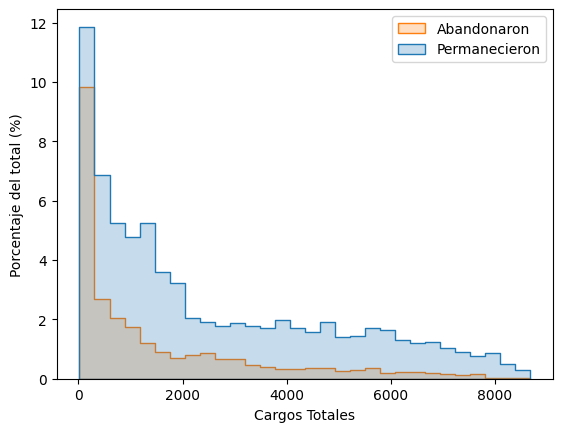

In [45]:
histogram().show()

In [46]:
def abandonaron():
  df_normalizado["antiguedad_bin"] = pd.cut(df_normalizado['Antigüedad'], bins=[0, 18, 36, 54, 72], right=False)
  churn_por_antig = (df_normalizado.groupby("antiguedad_bin", observed=False)["Abandonó_Servicio"].value_counts(normalize=True).unstack(fill_value=0) * 100)
  # Graficamos la columna [1]
  ax = churn_por_antig[1].plot(kind="line", marker="o", figsize=(10, 5), color="red")
  # Ajustes de etiquetas y leyenda
  ax.set_xlabel("Rango de Antigüedad (Meses)", fontsize=12, fontweight="bold")
  ax.set_ylabel("Tasa de Abandono (%)", fontsize=12, fontweight="bold")
  ax.legend(["Abandonaron"], loc="upper right")

  plt.grid(linestyle="--", alpha=0.6)
  plt.savefig("grafico_abandono.jpg", transparent=True)
  plt.show()
  return plt

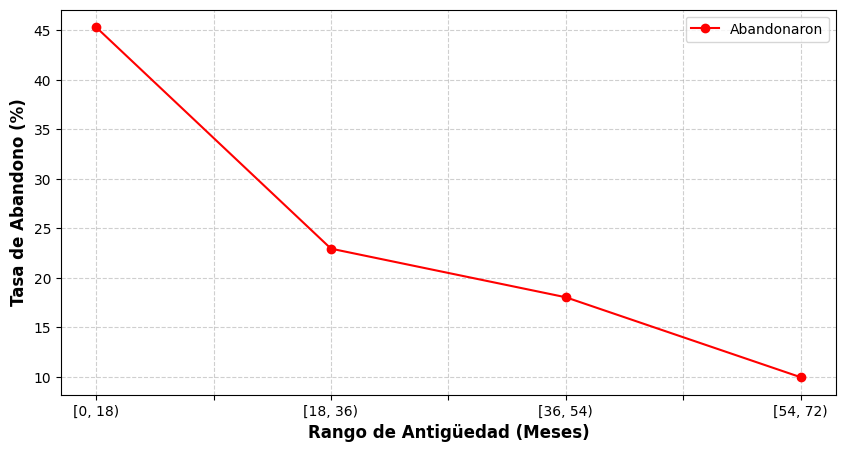

In [47]:
abandonaron().show()

##3.5 Correlación

In [48]:
matriz_corr = df_normalizado.corr(numeric_only=True)
print(matriz_corr)

                        Abandonó_Servicio  Cliente_Señor  Tiene_Pareja  \
Abandonó_Servicio                1.000000       0.150541     -0.149982   
Cliente_Señor                    0.150541       1.000000      0.016957   
Tiene_Pareja                    -0.149982       0.016957      1.000000   
Tiene_Dependientes              -0.163128      -0.210550      0.452269   
Antigüedad                      -0.354049       0.015683      0.381912   
Servicio_Telefónico              0.011691       0.008392      0.018397   
Múltiples_Líneas                 0.040033       0.142996      0.142561   
Seguridad_Online                -0.171270      -0.038576      0.143346   
Respaldo_Online                 -0.082307       0.066663      0.141849   
Protección_Dispositivo          -0.066193       0.059514      0.153556   
Soporte_Técnico                 -0.164716      -0.060577      0.120206   
TV_Streaming                     0.063254       0.105445      0.124483   
Películas_Streaming              0.060

#Informe final

> **Objetivo:** Identificar los factores que influyen en el abandono de clientes de TelecomX y proponer recomendaciones estratégicas para reducirlo.

---

## 1.  Descripción del Dataset

| Característica | Detalle |
|---|---|
| Registros originales | 7.267 |
| Registros tras limpieza | 7.032 |
| Variables analizadas | 22 |
| Variable objetivo | `Abandonó_Servicio` |

El dataset fue extraído en formato JSON anidado y normalizado en columnas planas. Se eliminaron 235 registros por valores vacíos en `Churn` y valores no numéricos en `Charges.Total`. No se encontraron duplicados.

---

## 2.  Proceso ETL

### Extracción
- Fuente: repositorio GitHub (Alura Cursos)
- Formato original: JSON con columnas anidadas (`customer`, `phone`, `internet`, `account`)

### Transformación
- Desanidado de columnas JSON con `pd.json_normalize`
- Eliminación de registros con `Churn` vacío y `Charges.Total` no numérico
- Conversión de variables binarias (`Yes`/`No`) a enteros (1/0)
- Traducción de columnas y valores al español
- Creación de variable derivada `Cargo_Diario` = `Cargo_Mensual / 30`
- Reset de índice para integridad del DataFrame

---

## 3.  Análisis Descriptivo

### Tasa de Abandono General

```
Clientes que permanecieron:  73.42%
Clientes que abandonaron:    26.58%  
```
> **1 de cada 4 clientes abandona el servicio.** Esta tasa supera el umbral crítico del 20%, requiriendo atención inmediata.

### Estadísticas Clave de Variables Numéricas

| Variable | Media | Rango |
|---|---|---|
| Antigüedad | 32 meses | 1 — 72 meses |
| Cargo Mensual | $64.80 | $18.25 — $118.75 |
| Cargo Total | $2,283 | $18.80 — $8,684 |
| Cargo Diario | $2.16 | $0.61 — $3.96 |

### Adopción de Servicios

| Servicio | Adopción |
|---|---|
| Servicio Telefónico | 90.33% |
| Facturación Sin Papel | 59.27% |
| Streaming (TV/Películas) | ~38–39% |
| Seguridad / Soporte / Protección | 28–34% |
| Clientes Senior | 16.24% |

---

## 4. Análisis por Variables Categóricas

###  Factores de Alto Riesgo (Churn > 40%)

| Factor | Tasa de Churn |
|---|---|
| Pago con Cheque Electrónico | 45.3% |
| Contrato Mensual | 42.7% |
| Servicio de Fibra Óptica | 41.9% |
| Cliente Senior | 41.7% |

###  Factores de Riesgo Moderado (Churn 30–35%)

| Factor | Tasa de Churn |
|---|---|
| Facturación Sin Papel | 33.6% |
| Sin Pareja | 33.0% |
| Sin Dependientes | 31.3% |

###  Factores de Bajo Riesgo (Churn < 20%)

| Factor | Tasa de Churn |
|---|---|
| Contrato Bienal | 2.8% |
| Sin Servicio de Internet | 7.4% |
| Contrato Anual | 11.3% |
| Con Dependientes | 15.5% |
| Servicio DSL | 18.9% |

>  **El género no representa un factor diferencial** (Femenino 27.0% vs Masculino 26.2%).

---

Claro, Francisca. Te lo reformulo con un tono más comercial y orientado a la toma de decisiones:

---

** Analisis de datos numericos Clave sobre Churn**

**Antigüedad y Retención**  
- Los clientes recientes (0–18 meses) son los más propensos a abandonar.  
- La fidelidad crece con el tiempo: mientras más antigüedad, menor tasa de churn.  
- Los clientes con más de 54 meses prácticamente no se van, consolidando una base estable.  

**Cargos Totales y Comportamiento de Pago**  
- Quienes se dan de baja suelen tener cargos acumulados bajos, lo que indica que se retiran antes de generar historial de pago.  
- Los clientes que permanecen muestran un rango más amplio de cargos, reflejando mayor compromiso y relación de largo plazo.  

### Cargos Totales vs Churn
- Los clientes que abandonan concentran sus cargos totales en valores **bajos**, indicando que se van **antes de acumular historial de pago**
- Los clientes que permanecen muestran una distribución más amplia de cargos totales

---

## 6.  Análisis de Correlaciones con Churn

### Correlaciones más relevantes con `Abandonó_Servicio`

| Variable | Correlación | Dirección |
|---|---|---|
| Antigüedad | -0.354 | 🔽 A mayor antigüedad, menor churn |
| Cargo Total | -0.199 | 🔽 A mayor gasto acumulado, menor churn |
| Facturación Sin Papel | +0.191 | 🔼 Asociado a mayor churn |
| Cargo Mensual | +0.193 | 🔼 Mayor cargo mensual, mayor riesgo |
| Tiene Dependientes | -0.163 | 🔽 Con dependientes, menor churn |
| Seguridad Online | -0.171 | 🔽 Con seguridad, menor churn |
| Soporte Técnico | -0.165 | 🔽 Con soporte, menor churn |
| Cliente Senior | +0.151 | 🔼 Clientes senior, mayor riesgo |

>  **La antigüedad es el predictor más fuerte del churn** (r = -0.354). Retener al cliente en los primeros 18 meses es crítico.

---

## 7. Conclusiones y Recomendaciones

### Perfil de Mayor Riesgo
> Cliente con **contrato mensual + fibra óptica + pago por cheque electrónico + sin vínculos familiares + antigüedad menor a 18 meses**

### Perfil de Menor Riesgo
> Cliente con **contrato bienal o anual + con pareja o dependientes + DSL + alta antigüedad**

### Recomendaciones Estratégicas

Perfecto, Francisca. Aquí tienes las recomendaciones expresadas con un tono más comercial y ejecutivo, orientado a la acción:

---

**Recomendaciones Estratégicas para Reducir el Churn**

1. **Impulsar contratos de mayor plazo**  
   Incentivar la migración de mensual a anual o bienal con beneficios exclusivos. La retención mejora drásticamente: de un churn del 42.7% baja a 11.3% y hasta 2.8%.  

2. **Fortalecer la experiencia inicial**  
   Los primeros 18 meses son críticos. Programas de onboarding, acompañamiento y comunicación activa pueden marcar la diferencia en la fidelización temprana.  

3. **Optimizar la propuesta de Fibra Óptica**  
   Con un churn del 41.9%, es clave revisar precios, calidad de servicio y soporte técnico para elevar la satisfacción y competitividad.  

4. **Promover servicios de valor agregado**  
   Seguridad Online y Soporte Técnico reducen el churn. Incentivar su adopción refuerza la percepción de valor y el compromiso del cliente.  

5. **Diseñar estrategias para clientes senior**  
   Aunque representan el 16.24% de la base, su churn es alto (41.7%). Se recomienda atención personalizada y planes adaptados a sus necesidades.  

6. **Simplificar métodos de pago**  
   Migrar clientes del cheque electrónico (45.3% churn) hacia pagos automáticos disminuye fricciones y asegura continuidad en la relación.  


*Este análisis, basado en 7.032 registros de TelecomX LATAM, revela oportunidades claras para transformar la retención en ventaja competitiva.*  
